## Tutorial: Membrane mechanics

This tutorial uses `triangulax` to study the mechanics of membranes. We numerically represent a membrane as a triangular mesh, and finds its mechanically balanced configuration by energy minimization, using automatic differentiation to calculate energy gradients.

In [1]:
import numpy as np
from scipy import sparse, optimize
import matplotlib.pyplot as plt
import meshplot

import igl

In [2]:
from IPython.display import IFrame

In [3]:
import jax.numpy as jnp
import jax

In [4]:
from jaxtyping import Float

In [5]:
jax.config.update("jax_enable_x64", True)
jax.config.update("jax_debug_nans", True)

In [6]:
import lineax
import optimistix

In [11]:
from triangulax import trigonometry as trig
from triangulax import geometry as geom
from triangulax import adjacency as adj
from triangulax import linops as lin
from triangulax.triangular import TriMesh
from triangulax.mesh import HeMesh, GeomMesh
from triangulax import linops
from triangulax import algorithms as algo

## Computing the mean curvature

The mean curvature of a surface (see [wikipedia](https://en.wikipedia.org/wiki/Differential_geometry_of_surfaces), and [Crane, Chpt. 5](https://www.cs.cmu.edu/~kmcrane/Projects/DDG/paper.pdf))
can be computed from the Laplace operator, applied to the vertex positions $\mathbf{v}$ as $\Delta\mathbf{v} = 2H\mathbf{n}$, where $\mathbf{n}$ is the surface normal. To compute the curvature $H$ numerically, one can also use the _dihedral angles_ $\theta_{ij}$ of each edge $ij$: the angles between the normal vectors of adjacent triangles. The mean curvature at vertex $i$ can be approximated by
$$H_i = \frac{1}{4a_i} \sum_{j\sim i} \ell_{ij} \theta_{ij} $$
where the sum is over all $j$ neighboring $i$, and $a_i$ is the Voronoi area around vertex $i$. This discretization can be more robust numerically. Both are already implemented in the `geometry` module.

In [12]:
# let's look at a torus which has varying mean curvature

torus = TriMesh.read_obj("tutorial_meshes/torus.obj",dim =3)
hemesh_torus = HeMesh.from_triangles(torus.vertices.shape[0], torus.faces)

# we can compute the mean curvature using two different methods

H_torus_lap = geom.get_mean_curvature_laplace(torus.vertices, hemesh_torus, normalize=True)
H_torus_dihed = geom.get_mean_curvature_dihedral(torus.vertices, hemesh_torus, normalize=True)

# however, not all discretizations are created equal. Using the barycentric area instead of the Voronoi area
# leads to inaccurate estimates

H_torus_barycentric = geom.get_mean_curvature_dihedral(torus.vertices, hemesh_torus, normalize=False)
H_torus_barycentric = H_torus_barycentric / geom.get_barycentric_cell_areas(torus.vertices, hemesh_torus)


  o Torus


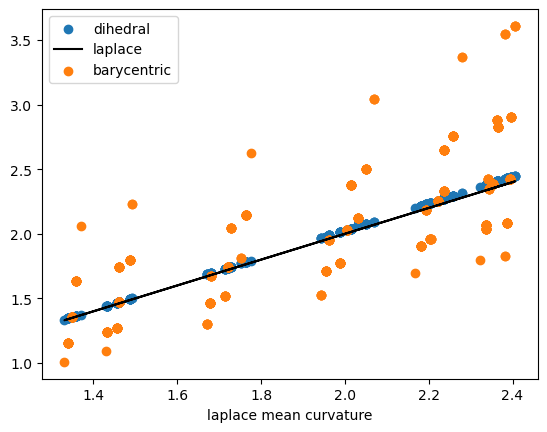

In [13]:
# the two methods for discretizing the mean curvature give similar results

plt.scatter(H_torus_lap, H_torus_dihed, label="dihedral")
plt.plot(H_torus_lap, H_torus_lap, color='k', label="laplace")
plt.scatter(H_torus_lap, H_torus_barycentric, label="barycentric")
plt.xlabel("laplace mean curvature")
plt.legend()

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0, 0.0,…

Plot saved to file tutorial_plots/05_torus_curvature.html.


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0, 0.0,…

Plot saved to file tutorial_plots/05_torus_curvature_barycentric.html.


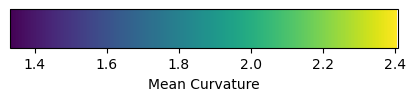

In [15]:
# top plot shows Voronoi, and bottom plot barycentric normalization

p1 = meshplot.plot(np.array(torus.vertices), np.array(hemesh_torus.faces), np.array(H_torus_lap),
                   shading={"wireframe": True})
p1.save("tutorial_plots/05_torus_curvature.html")
p2 = meshplot.plot(np.array(torus.vertices), np.array(hemesh_torus.faces), np.array(H_torus_barycentric),
              shading={"wireframe": True})
p2.save("tutorial_plots/05_torus_curvature_barycentric.html")

# add a colorbar
fig, ax = plt.subplots(figsize=(5, 0.5))
sm = plt.cm.ScalarMappable(cmap='viridis',norm=plt.Normalize(vmin=np.array(H_torus_lap).min(),
                                                             vmax=np.array(H_torus_lap).max()))
cbar = fig.colorbar(sm, cax=ax, orientation='horizontal')
cbar.set_label('Mean Curvature')
plt.show()


In [16]:
IFrame(src="tutorial_plots/05_torus_curvature.html", width="100%", height=400); # for display in docs webpage

In [17]:
IFrame(src="tutorial_plots/05_torus_curvature_barycentric.html", width="100%", height=400); 

## Minimal surfaces

As a first example, let's consider a membrane $\mathcal{M}$ whose energy is dominated by surface tension, so the energy is proportional to the membrane area $E_A = \int_{\mathcal{M}} dA$. Note that moving vertices _within_ the plane of the mesh does not change the total area/energy (physically, this is because membranes are fluid in-plane, rather than thin elastic sheets). This has important numerical consequences: we will want to arrange the mesh vertices so as to avoid a highly distorted mesh with very stretched triangles.

A nice algorithm by [Pinkall and Poitier](https://projecteuclid.org/journalArticle/Download?urlId=em%2F1062620735) takes care of this problem. It uses the discretized Laplacian which we already used in the previous notebook for the heat equation. 
The idea is that to minimize the area, the position of a vertex $\mathbf{v}_i$ should be equal to the (geometry-weighted) average of its neighbors, and therefore $\Delta \mathbf{v}_i = 0$. The resulting iterative algorithm works as follows.

1. Given the vertex-positions $\mathbf{v}_i^{(t)}$ at step $t$, compute the cotan-Laplacian matrix $\Delta^{(t)}_{ij}$
2. Solve $\Delta^{(t)}_{ij} \cdot \mathbf{v}_i^{(t+1)} =0$, subject to fixed boundary conditions.

  o flat_tri_ecmc


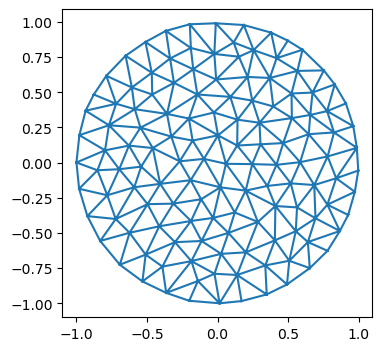

In [18]:
# let's load a simple test mesh

trimesh = TriMesh.read_obj("tutorial_meshes/disk.obj", dim=3)
hemesh = HeMesh.from_triangles(trimesh.vertices.shape[0], trimesh.faces)

fig = plt.figure(figsize=(4,4))
plt.triplot(*trimesh.vertices[:,:2].T, trimesh.faces)
plt.axis("equal");

In [19]:
# let's impose some boundary conditions on the disk mesh - think of this as finding the shape of a "soap film"
# with a given boundary curve.

bdry_verts = np.where(hemesh.is_bdry)[0]
interior_verts = np.where(~hemesh.is_bdry)[0]

phi_bdry = np.atan2(*trimesh.vertices[bdry_verts, :2].T)
h = 0.5*np.sin(2*phi_bdry)
bdry_pos = np.array(trimesh.vertices[bdry_verts, :])
bdry_pos[:, -1] = h

vertices_bdry_imposed = np.copy(trimesh.vertices)
vertices_bdry_imposed[bdry_verts] = bdry_pos

In [20]:
# the non-optimized membrane is pretty creased

p = meshplot.plot(vertices_bdry_imposed, hemesh.faces, shading={"wireframe":False}, return_plot=True)
p.save("tutorial_plots/05_minimal_surface_initial.html")

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.001874…

Plot saved to file tutorial_plots/05_minimal_surface_initial.html.


In [21]:
IFrame(src="tutorial_plots/05_minimal_surface_initial.html", width="100%", height=400);

In [22]:
# compute the area of the initial configuration - this is the energy we will minimize
initial_area = geom.get_area(vertices_bdry_imposed, hemesh)
print(f"Initial area: {initial_area:.4f}")

Initial area: 4.3650


In [23]:
# let's check the cotan-Laplacian gives us the area via A = 1/2 * v^T L v, where v are the vertex positions

L = linops.cotan_laplace_sparse(vertices_bdry_imposed, hemesh)
area_L = -jnp.diag(vertices_bdry_imposed.T.dot(L @ vertices_bdry_imposed)).sum() /2

print(f"Initial area from Laplace operator: {area_L:.4f}")

Initial area from Laplace operator: 4.3650


In [24]:
# Let's use the iterative Pinkall-Poitier method to find the mininum energy configuration.

vertices_iterated = [np.copy(vertices_bdry_imposed)] 

for t in range(10):
    L = linops.bcoo_to_scipy(linops.cotan_laplace_sparse(vertices_iterated[-1], hemesh)) # compute Laplace matrix

    # impose boundary conditions by splitting the Laplace matrix into interior and boundary vertices
    L_ii = L[interior_verts, :][:, interior_verts] 
    L_ib = L[interior_verts, :][:, bdry_verts]
    bcs = vertices_bdry_imposed[bdry_verts,:]
    
    new_vertices = np.zeros_like(vertices_iterated[-1])
    new_vertices[bdry_verts] = bcs

    solution = np.stack([sparse.linalg.spsolve(-L_ii, L_ib.dot(bc)) for bc in bcs.T], axis=-1)
    # iterate over x/y/z coordinates
    new_vertices[interior_verts] = solution
    vertices_iterated.append(new_vertices)

In [25]:
# as a result of the optimization, we get an area-minimizing "Pringles" surface

p = meshplot.plot(vertices_iterated[-1], hemesh.faces, shading={"wireframe":True}, return_plot=True)
p.save("tutorial_plots/05_minimal_surface_final.html")

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.001874…

Plot saved to file tutorial_plots/05_minimal_surface_final.html.


In [26]:
IFrame(src="tutorial_plots/05_minimal_surface_final.html", width="100%", height=400);

In [27]:
final_area = geom.get_area(vertices_iterated[-1], hemesh)
print(f"Initial area: {initial_area:.4f}", f"Final area: {final_area:.4f}")

Initial area: 4.3650 Final area: 3.7981


In [28]:
# the gradient of the area is very small after optimization:   

(jnp.linalg.norm(jax.grad(geom.get_area)(vertices_iterated[0], hemesh), axis=-1)[interior_verts].mean(),
 jnp.linalg.norm(jax.grad(geom.get_area)(vertices_iterated[-1], hemesh), axis=-1)[interior_verts].mean())

(Array(0.06015605, dtype=float64), Array(0.00068703, dtype=float64))

In [29]:
# the mean curvature is also very small after optimization, as expected for a minimal surface:
H_laplace = geom.get_mean_curvature_laplace(vertices_iterated[-1], hemesh)
jnp.abs(H_laplace).mean()


Array(0.06962044, dtype=float64)

### Helfrich energy

Next, let's consider a membrane for which the surface tension is negligible. This is the case for many of the lipid bilayer membranes that make up the cell and its interior organelles. Instead, the energy is dominated by _bending_.

The _Helfrich energy_ is an elegant, geometric model of bending energy. It uses the mean and Gaussian curvatures $H, K$ of the surface $\mathcal{M}$. The energy reads:

$$E_H  =\int dA \left( \frac{\kappa_H}{2}(H-H_0)^2 + \kappa_G K \right) $$

If the surface is closed, the $\int K$-term is a topological invariant and can be dropped (and we will do so here). 
A nonzero _spontaneous curvature_ $H_0$ means that the membrane "prefers" to be curved; this can result, for instance, from molecules that bind to the membrane.

In [30]:
# let's load a sphere as a test mesh for the Helfrich energy

trimesh = TriMesh.read_obj("tutorial_meshes/sphere_fine.obj", dim=3) # sphere_fine sphere

trimesh.vertices -= trimesh.vertices.mean(axis=0)
trimesh.vertices = (trimesh.vertices.T / np.linalg.norm(trimesh.vertices, axis=1)).T

hemesh = HeMesh.from_triangles(trimesh.vertices.shape[0], trimesh.faces)

  o Icosphere


In [ ]:
p = meshplot.plot(np.array(trimesh.vertices), np.array(hemesh.faces),
                  shading={"wireframe":True}, return_plot=True)
p.save("tutorial_plots/05_sphere_mesh.html")

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0, 0.0,…

In [34]:
IFrame(src="tutorial_plots/05_sphere_mesh.html", width="100%", height=400);

In [35]:
# let's define the discrete Helfrich energy.

@jax.jit
def get_helfrich_energy(vertices, args):
    """Compute the discrete Helfrich energy of a triangulated surface. args = (hemesh, H0, kappa)"""
    hemesh, H0, kappa = args
    # the cell areas are needed to discretize the area integral
    cell_areas = geom.get_voronoi_areas_robust(vertices, hemesh)
    #H = geom.get_mean_curvature_laplace(vertices, hemesh)
    H = geom.get_mean_curvature_dihedral(vertices, hemesh, normalize=True)

    return (kappa/2) * ((H - H0) **2 * cell_areas).sum()

In [36]:
args = (hemesh, 0, 1)
# exact helfrich for a sphere is 2*pi, here smaller due to discretization error. The energy is scale invariant.
get_helfrich_energy(trimesh.vertices, args), get_helfrich_energy(2*trimesh.vertices, args), 2*np.pi

(Array(6.29326108, dtype=float64),
 Array(6.29326108, dtype=float64),
 6.283185307179586)

In [37]:
# now, let's deform the sphere and minimize the Helfrich energy to find the equilibrium shape.

deformed_vertices = trimesh.vertices.at[:, 1].add(0.5*trimesh.vertices[:, 1]**3)
deformed_vertices = trimesh.vertices.at[:, 2].add(0.5*trimesh.vertices[:, 0]**3)

print("Minimum vs deformed energy:", get_helfrich_energy(trimesh.vertices, args),
                                     get_helfrich_energy(deformed_vertices, args))

Minimum vs deformed energy: 6.293261081171555 7.118657237550066


In [40]:
p = meshplot.plot(np.array(deformed_vertices), np.array(hemesh.faces),
                  shading={"wireframe":True}, return_plot=True)
p.save("tutorial_plots/05_sphere_mesh_deformed.html")

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0, 0.0,…

Plot saved to file tutorial_plots/05_sphere_mesh_deformed.html.


In [41]:
IFrame(src="tutorial_plots/05_sphere_mesh_deformed.html", width="100%", height=400);

In [42]:
# we can compute the energy gradient using JAX

grad = jax.grad(get_helfrich_energy)(deformed_vertices, args)
normal = geom.get_vertex_normals(deformed_vertices, hemesh)
grad_norm = jnp.linalg.norm(grad, axis=-1)

 # gradient is along normal

(jnp.abs(jnp.linalg.vecdot(grad, normal)) / grad_norm).mean()

Array(0.99466172, dtype=float64)

In [43]:
# the gradient computed via autodiff matches the finite difference approximation

eps = 1e-2
step = eps * normal / jnp.linalg.norm(normal)

grad_autodiff = jnp.sum(grad * step)
grad_fd = (get_helfrich_energy(deformed_vertices+step, args) - get_helfrich_energy(deformed_vertices, args))

1e4*grad_autodiff, 1e4*grad_fd

(Array(-9.05360294, dtype=float64), Array(-9.04334675, dtype=float64))

#### Nonlinear minimization

To minimize the energy, we can use one of many non-linear minimization algorithms, all of which use the gradient $\nabla E_H$ which we can compute using JAX. Here, we use the JAX-based optimization library `optimistix`.

In [44]:
#solver = optimistix.GradientDescent(rtol=1e-8, atol=1e-8, learning_rate=0.5*1e-2)
solver = optimistix.NonlinearCG(rtol=1e-8, atol=1e-8)

y0 = deformed_vertices
args = (hemesh, 0, 1) 

sol = optimistix.minimise(get_helfrich_energy, solver, y0, args, max_steps=10000, throw=False)
vertices_final = sol.value

In [45]:
print("Initial/final/minimal energy:", get_helfrich_energy(y0, args),
                                       get_helfrich_energy(sol.value, args),
                                       get_helfrich_energy(trimesh.vertices, args))

Initial/final/minimal energy: 7.118657237550066 6.300880738246545 6.293261081171555


In [46]:
# displacement from initial condition.

jnp.linalg.norm(y0-sol.value, axis=-1).mean(), jnp.linalg.norm(y0-trimesh.vertices, axis=-1).mean() 

(Array(0.03848122, dtype=float64), Array(0.12507872, dtype=float64))

In [47]:
# after minimization, the deviation from being a perfect sphere is fairly low

center = jnp.average(vertices_final, weights=geom.get_voronoi_areas(vertices_final, hemesh), axis=0)
Rs =  jnp.linalg.norm(vertices_final - center, axis=1)

Rs.std() / Rs.mean()

Array(0.01461819, dtype=float64)

In [49]:
p = meshplot.plot(np.array(y0), np.array(hemesh.faces), np.array(grad_norm),shading={"wireframe":True},
                  return_plot=True)
p.add_mesh(np.array(sol.value) + np.array([0, 0, 3]), np.array(hemesh.faces), shading={"wireframe":True})
p.save("tutorial_plots/05_helfrich_optimization.html")

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0, 0.0,…

Plot saved to file tutorial_plots/05_helfrich_optimization.html.


In [50]:
IFrame(src="tutorial_plots/05_helfrich_optimization.html", width="100%", height=400);

## Constrained minimization using Penalty and Augmented Lagrangian methods

Much of the physics of membranes arises from balancing the Helfrich bending energy with constraints on the volume $V$ and area $A$ of the membrane. For simplicity, we softly enforce these contrstraints with quadratic penalty terms in the energy:
$$E_P =  \mu_V(V-V_0)^2/(2V_0) + \mu_A(A-A_0)^2/(2A_0)$$


In [51]:
trimesh = TriMesh.read_obj("tutorial_meshes/sphere_fine.obj", dim=3)
trimesh.vertices -= trimesh.vertices.mean(axis=0)
trimesh.vertices = (trimesh.vertices.T / np.linalg.norm(trimesh.vertices, axis=1)).T

hemesh = HeMesh.from_triangles(trimesh.vertices.shape[0], trimesh.faces)

  o Icosphere


In [52]:
# verify volume and area on the sphere mesh
A_sphere = geom.get_area(trimesh.vertices, hemesh)
V_sphere = geom.get_volume(trimesh.vertices, hemesh)
print(f"Sphere area: {A_sphere:.4f} (exact 4π = {4*jnp.pi:.4f})")
print(f"Sphere volume: {V_sphere:.4f} (exact 4π/3 = {4*jnp.pi/3:.4f})")

Sphere area: 12.5062 (exact 4π = 12.5664)
Sphere volume: 4.1527 (exact 4π/3 = 4.1888)


In [53]:
@jax.jit
def get_helfrich_energy_with_penalty(vertices, args):
    """Discrete Helfrich energy with quadratic area/volume penalties.
    args = (hemesh, H0, kappa, mu_A, mu_V, A0, V0)"""
    hemesh, H0, kappa, mu_A, mu_V, A0, V0 = args
    E = get_helfrich_energy(vertices, (hemesh, H0, kappa))
    penalty_area = mu_A/2 * (geom.get_area(vertices, hemesh) - A0)**2 / A0
    penalty_volume = mu_V/2 * (geom.get_volume(vertices, hemesh) - V0)**2 / V0**2
    return E + penalty_area + penalty_volume

In [60]:
A0 = geom.get_area(trimesh.vertices, hemesh)
V0 = 0.8 * geom.get_volume(trimesh.vertices, hemesh)
kappa, H0 = 1.0, 0.0
mu_A = 300.0
mu_V = 600.0
args = (hemesh, H0, kappa, mu_A, mu_V, A0, V0)

y0 = trimesh.vertices * np.array([1, 1.05, 1]) # start from stretched configuration to break symmetrty

In [61]:
solver = optimistix.GradientDescent(rtol=1e-8, atol=1e-8, learning_rate=1e-3)
#solver = optimistix.NonlinearCG(rtol=1e-8, atol=1e-8)

sol = optimistix.minimise(get_helfrich_energy_with_penalty, solver, y0, args, max_steps=10000, throw=False)


vertices_final = sol.value

In [62]:
# constraints are approximately satisfied after optimization
geom.get_area(vertices_final, hemesh)/A0, geom.get_volume(vertices_final, hemesh)/V0

(Array(0.99227256, dtype=float64), Array(1.03085984, dtype=float64))

In [64]:
p = meshplot.plot(np.array(y0), np.array(hemesh.faces), np.array(grad_norm),
                  shading={"wireframe":True}, return_plot=True)

p.add_mesh(np.array(sol.value) + np.array([3, 0, 0]), np.array(hemesh.faces), shading={"wireframe":True})
p.save("tutorial_plots/05_constrained_optimization.html")

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0, 0.0,…

Plot saved to file tutorial_plots/05_constrained_optimization.html.


In [58]:
IFrame(src="tutorial_plots/05_constrained_optimization.html", width="100%", height=400);

### Regularization tangential mesh motion

If you play around with the above code, you will notice that it is rather unstable (try using a different minimizer). The reason is the _reparametrization_ invariance of the Helfrich energy - moving vertices in the local tangent plane does not change the energy. 
This means the optimization landscape has flat directions that cause mesh degeneration, leading to numerical instability. To avoid this, we can add a smoothing step that repositions the vertices tangentially to improve mesh quality between energy minimization steps.

In [65]:
solver = optimistix.NonlinearCG(rtol=1e-8, atol=1e-8)

vertices_smoothed = y0
n_iterations = 50
n_smoothing = 10
smoothing_step_size = 0.1
n_minimization = 100

for i in range(n_iterations):
    sol = optimistix.minimise(get_helfrich_energy_with_penalty, solver, vertices_smoothed, args,
    max_steps=n_minimization, throw=False)
    vertices_smoothed = sol.value
    for j in range(n_smoothing):
        vertices_smoothed = algo.smooth_vertices_laplacian(vertices_smoothed, hemesh, step_size=smoothing_step_size)

In [66]:
geom.get_area(vertices_smoothed, hemesh)/A0, geom.get_volume(vertices_smoothed, hemesh)/V0

(Array(0.9956919, dtype=float64), Array(1.01755651, dtype=float64))

In [69]:
p = meshplot.plot(np.array(y0), np.array(hemesh.faces), np.array(grad_norm),
                  shading={"wireframe":True}, return_plot=True)
p.add_mesh(np.array(vertices_smoothed) + np.array([3, 0, 0]), np.array(hemesh.faces),
           shading={"wireframe":True})

p.save("tutorial_plots/05_constrained_optimization_smoothed.html")

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0, 0.0,…

Plot saved to file tutorial_plots/05_constrained_optimization_smoothed.html.


In [70]:
IFrame(src="tutorial_plots/05_constrained_optimization_smoothed.html", width="100%", height=400);

### Split normal–tangential optimization

More generally, we can address the reparametrization invariance and the resulting mesh degeneracy issues by **splitting vertex updates** into two independent sub-problems:

1. **Normal phase**: minimize the physical energy $E_N$ (Helfrich + constraints) by moving vertices only along surface normals.
2. **Tangential phase**: minimize a conformal regularization energy $E_T$ by moving vertices only in the tangent plane.

We **reparametrize** each sub-problem and express vertex displacements in the local normal/tangent basis (recomputed each outer iteration), then run a standard unconstrained optimizer on the reduced coordinates. This is compatible with any optimizer (CG, L-BFGS, ...).

**Parametrization energy.** For $E_T$, many choices are possible. We use the _neo-Hookean_ energy:

$$E_{\mathrm{NH}} = \sum_f A_f \left[ \frac{K}{2}\left(\frac{\mathrm{tr}(C_f)}{\sqrt{\det C_f}} - 2\right)
+\frac{G}{2}\left(\sqrt{\det C_f} - 1\right)^2
\right], \qquad C_f = G_0^{-1} G$$

Here, $C_f$ is the Cauchy-Green tensor (a nonlinear measure of strain), computed from $G$, $G_0$ the current and reference metric tensors. They are easily evaluated for each triangle $f$. The total energy sums over all faces, weighted by area $A_f$. $K$ and $G$ are the bulk and shear moduli

An important special case is $G=0$ (zero bulk modulus), in which triangle shear relative to a reference is penalized. The energy reduces to the LSCM (Least Squares Conformal Mapping) energy, which is invariant to uniform area changes. Penalizing shear is particularly important, since it more rapidly leads to numerical divergence than area changes, which only result in loosing detail.

In [71]:
# --- Mesh energies ---

def get_metric(vertices: Float[jax.Array, "n_faces dim"],
               hemesh: HeMesh) -> Float[jax.Array, "n_faces 2 2"]:
    """Metric tensor (first fundamental form) per triangle."""
    a, b, c = vertices[hemesh.faces.T]
    J = jnp.stack([b - a, c - a], axis=1)
    return jnp.einsum("vix,vjx->vij", J, J)


def get_lscm_energy_density(C: Float[jax.Array, "2 2"]) -> Float[jax.Array, ""]:
    """LSCM conformal energy density from Cauchy-Green tensor C:
        E = trace(C) / (2*sqrt(det(C))) - 1
    Zero iff the map is conformal (angle-preserving). Scale-invariant.
    """
    return jnp.trace(C) / (2 * jnp.sqrt(jnp.linalg.det(C))) - 1


@jax.jit
def get_conformal_energy(vertices, args):
    """Total LSCM conformal energy. args = (hemesh, metric_ref)"""
    hemesh, metric_ref = args
    areas = geom.get_triangle_areas(vertices, hemesh)
    C = jnp.einsum("fij,fjk->fik", jnp.linalg.inv(metric_ref), get_metric(vertices, hemesh))
    return (areas * jax.vmap(get_lscm_energy_density)(C)).sum()


def get_neo_hookean_energy_density(C: Float[jax.Array, "2 2"], mod_bulk: float, mod_shear: float
                                   ) -> Float[jax.Array, ""]:
    """Compute the neo-Hookean energy density from Cauchy-Green deformation tensor C:
        E = mod_shear/2 * (trace(C) / J - 2) + mod_bulk/2 * (J - 1)^2
    where J = sqrt(det(C)) is the local area change.
    See https://en.wikipedia.org/wiki/Neo-Hookean_solid
    """
    J = jnp.sqrt(jnp.linalg.det(C))
    return mod_shear/2*(jnp.trace(C)/J - 2) + mod_bulk/2*(J-1)**2


@jax.jit
def get_neo_hookean_energy(vertices, args):
    """Total neo-Hookean energy. args = (hemesh, metric_ref, mod_bulk, mod_shear)"""
    hemesh, metric_ref, mod_bulk, mod_shear = args
    areas = geom.get_triangle_areas(vertices, hemesh)
    C = jnp.einsum("fij,fjk->fik", jnp.linalg.inv(metric_ref), get_metric(vertices, hemesh))
    return (areas * jax.vmap(lambda c: get_neo_hookean_energy_density(c, mod_bulk, mod_shear))(C)).sum()


In [72]:
# Test: conformal energy is zero for uniform scaling, nonzero for shear

C_identity = jnp.eye(2)
C_scaled = 4 * jnp.eye(2)  # uniform 2× scaling → det=4, tr=4, energy = 4/(2*2)-1 = 0
C_sheared = jnp.array([[1.5, 0.3], [0.3, 0.8]])

print("Identity:", get_lscm_energy_density(C_identity))
print("Uniform scale:", get_lscm_energy_density(C_scaled))
print("Sheared:", get_lscm_energy_density(C_sheared))

Identity: 0.0
Uniform scale: 0.0
Sheared: 0.09153169511537373


As a warmup, let's minimize the physical and parametrization energies by projected gradient descent:
1. Compute the current surface normals $\mathbf{n}$ 
2. Compute the parametrization and physical energy gradients $\nabla E_{LSCM}, \nabla E_N$
3. Move vertices by projecting the physical gradient onto the normal and the parametrization gradient onto the tangential direction:
    $$\mathbf{v} \rightarrow \mathbf{v} + \eta \left(P_\mathbf{n}\cdot \nabla E_N + (\mathbb{I}-P_\mathbf{n})\cdot \nabla E_{LSCM}  \right) $$
    where $P_\mathbf{n} = \mathbf{n} \otimes\mathbf{n}$ is the projecion operator

In [73]:
A0 = geom.get_area(trimesh.vertices, hemesh)
V0 = 0.75 * geom.get_volume(trimesh.vertices, hemesh)
metric_orig = get_metric(trimesh.vertices, hemesh)

kappa, H0 = 1.0, 0.0
mu_A, mu_V = 300.0, 600.0
args_helfrich_penalty = (hemesh, H0, kappa, mu_A, mu_V, A0, V0)

#mod_conformal = 1.0 # strength of regularization
#args_elastic = (hemesh, metric_orig)

mod_bulk, mod_shear = 1.0, 1.0 # strength of regularization
args_elastic = (hemesh, metric_orig, mod_bulk, mod_shear)

step_size = 0.5*1e-3

@jax.jit
def get_step(vertices):
    grad_helfrich = jax.grad(get_helfrich_energy_with_penalty)(vertices, args_helfrich_penalty)
    #grad_elastic = mod_conformal * jax.grad(get_conformal_energy)(vertices, args_elastic)
    grad_elastic = jax.grad(get_neo_hookean_energy)(vertices, args_elastic)
    
    normals = geom.get_vertex_normals(vertices, hemesh)
    step = (jax.vmap(trig.project_out_vector)(grad_elastic, normals) +
            jax.vmap(trig.project_on_vector)(grad_helfrich, normals))
    return step

In [74]:
n_iterations = 20000

vertices_initial = trimesh.vertices * np.array([0.95, 1.1, 0.95]) # start from a stretched configuration
v_opt = jnp.copy(vertices_initial)
for t in range(n_iterations):
    v_opt = v_opt - step_size * get_step(v_opt)

In [75]:
# check constraints and mesh quality

grad_helfrich = jax.grad(get_helfrich_energy_with_penalty)(v_opt, args_helfrich_penalty)
print(f"Physical energy gradient norm: {jnp.linalg.norm(grad_helfrich, axis=-1).mean():.4f}")
print(f"A/A0 = {geom.get_area(v_opt, hemesh)/A0:.4f},  V/V0 = {geom.get_volume(v_opt, hemesh)/V0:.4f}")
print(f"Helfrich energy: {get_helfrich_energy(v_opt, (hemesh, H0, kappa)):.4f}")
algo.get_mesh_quality_stats(v_opt, hemesh)

Physical energy gradient norm: 0.0034
A/A0 = 0.9952,  V/V0 = 1.0198
Helfrich energy: 9.1686


{'areas_min': 0.00514,
 'areas_max': 0.01719,
 'areas_cv': 0.39562,
 'max_angle': 101.60694,
 'min_angle': 29.72937,
 'angles_std': 18.56349,
 'n_degenerate': 0,
 'n_total_faces': 1280}

In [77]:
p = meshplot.plot(np.array(vertices_initial), np.array(hemesh.faces),
                  shading={"wireframe":True}, return_plot=True)

p.add_mesh(np.array(v_opt) + np.array([3, 0, 0]), np.array(hemesh.faces), shading={"wireframe":True})
p.save("tutorial_plots/05_constrained_optimization_gradient_descent.html")

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0, 0.0,…

Plot saved to file tutorial_plots/05_constrained_optimization_gradient_descent.html.


In [79]:
IFrame(src="tutorial_plots/05_constrained_optimization_gradient_descent.html", width="100%", height=400);

Now we turn to the more sophisticated method described above: using an arbitrary optimizer for the normal and tangential subproblems.

In [80]:
# --- Reparametrization wrappers ---
# These let any optimizer minimize over normal-only or tangent-only displacements.

def make_normal_energy(energy_fn, v0: Float[jax.Array, "n 3"],
                       normals: Float[jax.Array, "n 3"]):
    """Wrap energy_fn(vertices, args) to optimize over normal heights h ∈ ℝⁿ.

    vertices(h) = v0 + h[:, None] * normals.
    """
    def energy(h, args):
        return energy_fn(v0 + h[:, None] * normals, args)
    return energy


def make_tangential_energy(energy_fn, v0: Float[jax.Array, "n 3"],
                           basis: Float[jax.Array, "n 2 3"]):
    """Wrap energy_fn(vertices, args) to optimize over tangent coords t ∈ ℝⁿˣ².

    vertices(t) = v0 + einsum('vi,vid->vd', t, basis).
    """
    def energy(t, args):
        return energy_fn(v0 + jnp.einsum("vi,vid->vd", t, basis), args)
    return energy


def vertices_from_normal(v0, h, normals):
    """Reconstruct vertices from base + normal displacement."""
    return v0 + h[:, None] * normals


def vertices_from_tangential(v0, t, basis):
    """Reconstruct vertices from base + tangential displacement."""
    return v0 + jnp.einsum("vi,vid->vd", t, basis)

In [81]:
def alternating_minimize(energy_normal_fn, args_normal,
                        energy_tangential_fn, args_tangential,
                        vertices, hemesh,
                        solver_normal=None, solver_tangential=None,
                        n_outer: int = 20,
                        n_inner_normal: int = 100, n_inner_tangential: int = 50,
                        verbose: bool = True):
    """Alternating normal–tangential optimization.

    Parameters
    ----------
    energy_normal_fn : callable
        Physical energy: (vertices, args_normal) → scalar.
    args_normal
        Arguments for the physical energy.
    energy_tangential_fn : callable
        Mesh regularization energy: (vertices, args_tangential) → scalar.
    args_tangential
        Arguments for the regularization energy.
    vertices : Float[Array, "n 3"]
        Initial vertex positions.
    hemesh : HeMesh
        Half-edge mesh connectivity.
    solver_normal, solver_tangential : optimistix solver, optional
        Solvers for normal and tangential phases. Default: NonlinearCG.
    n_outer : int
        Number of alternating iterations.
    n_inner_normal, n_inner_tangential : int
        Max inner steps per phase.
    verbose : bool
        Print diagnostics each iteration.

    Returns
    -------
    vertices : Float[Array, "n 3"]
        Optimized vertex positions.
    history : list[dict]
        Per-iteration diagnostics.
    """
    solver_normal = solver_normal or optimistix.NonlinearCG(rtol=1e-8, atol=1e-8)
    solver_tangential = solver_tangential or optimistix.NonlinearCG(rtol=1e-8, atol=1e-8)
    history = []

    for k in range(n_outer):
        normals = geom.get_vertex_normals(vertices, hemesh)
        basis = geom.get_vertex_tangent_basis(vertices, hemesh)

        # --- Phase 1: normal ---
        E_normal = make_normal_energy(energy_normal_fn, vertices, normals)
        h0 = jnp.zeros(vertices.shape[0])
        sol_n = optimistix.minimise(E_normal, solver_normal, h0, args_normal,
                                    max_steps=n_inner_normal, throw=False)
        vertices = vertices_from_normal(vertices, sol_n.value, normals)

        # --- Phase 2: tangential ---
        E_tangential = make_tangential_energy(energy_tangential_fn, vertices, basis)
        t0 = jnp.zeros((vertices.shape[0], 2))
        sol_t = optimistix.minimise(E_tangential, solver_tangential, t0, args_tangential,
                                    max_steps=n_inner_tangential, throw=False)
        vertices = vertices_from_tangential(vertices, sol_t.value, basis)

        # --- Diagnostics ---
        stats = algo.get_mesh_quality_stats(vertices, hemesh)
        E_phys = float(energy_normal_fn(vertices, args_normal))
        E_param = float(energy_tangential_fn(vertices, args_tangential))
        record = {"iter": k, "E_phys": E_phys, "E_param": E_param, **stats}
        history.append(record)

        if verbose:
            print(f"  {k:3d} | E_phys={E_phys:.4f} | E_param={E_param:.6f} | "
                  f"angles=[{stats['min_angle']:.1f}°, {stats['max_angle']:.1f}°] | "
                  f"degen={stats['n_degenerate']}")

    return vertices, history

In [82]:
# --- Demo: deflated sphere with alternating minimization ---

A0 = geom.get_area(trimesh.vertices, hemesh)
V0 = 0.75 * geom.get_volume(trimesh.vertices, hemesh)
metric_ref = get_metric(trimesh.vertices, hemesh)

kappa, H0 = 1.0, 0.0
mu_A, mu_V = 300.0, 600.0
args_helfrich = (hemesh, H0, kappa, mu_A, mu_V, A0, V0)
args_conformal = (hemesh, metric_ref)

mod_bulk, mod_shear = 1.0, 1.0
args_elastic = (hemesh, metric_ref, mod_bulk, mod_shear)

# start from a slightly stretched configuration to break spherical symmetry
vertices_initial = trimesh.vertices * np.array([0.95, 1.1, 0.95])

solver_normal =  optimistix.NonlinearCG(rtol=1e-8, atol=1e-8) # NonlinearCG, BFGS OK. LBFGS bad. 
solver_tangential = optimistix.NonlinearCG(rtol=1e-8, atol=1e-8)

#solver_normal =  optimistix.GradientDescent(rtol=1e-8, atol=1e-8, learning_rate=1e-3)
#solver_tangential = optimistix.GradientDescent(rtol=1e-8, atol=1e-8, learning_rate=1e-3)

v_opt, history = alternating_minimize(
    get_helfrich_energy_with_penalty, args_helfrich,
    #get_conformal_energy, args_conformal,
    get_neo_hookean_energy, args_elastic,
    vertices_initial, hemesh,
    solver_normal=solver_normal, solver_tangential=solver_tangential,
    n_outer=16, n_inner_normal=100, n_inner_tangential=50)

    0 | E_phys=26.0211 | E_param=0.196062 | angles=[46.7°, 71.4°] | degen=0
    1 | E_phys=19.3567 | E_param=0.366492 | angles=[43.5°, 75.3°] | degen=0
    2 | E_phys=17.9201 | E_param=0.545279 | angles=[41.3°, 78.6°] | degen=0
    3 | E_phys=16.7203 | E_param=0.591944 | angles=[40.5°, 79.1°] | degen=0
    4 | E_phys=14.7309 | E_param=1.340135 | angles=[34.4°, 85.3°] | degen=0
    5 | E_phys=13.1544 | E_param=1.377557 | angles=[34.1°, 88.6°] | degen=0
    6 | E_phys=12.5392 | E_param=1.409830 | angles=[33.6°, 88.0°] | degen=0
    7 | E_phys=11.5859 | E_param=1.574422 | angles=[32.9°, 91.0°] | degen=0
    8 | E_phys=11.0638 | E_param=1.691598 | angles=[31.9°, 92.5°] | degen=0
    9 | E_phys=10.7870 | E_param=1.695385 | angles=[31.7°, 92.4°] | degen=0
   10 | E_phys=9.8910 | E_param=2.236055 | angles=[29.8°, 98.9°] | degen=0
   11 | E_phys=9.5247 | E_param=2.270048 | angles=[29.4°, 98.8°] | degen=0
   12 | E_phys=9.4930 | E_param=2.303603 | angles=[29.0°, 98.6°] | degen=0
   13 | E_phys=

In [83]:
# check constraints and mesh quality
grad_helfrich = jax.grad(get_helfrich_energy_with_penalty)(v_opt, args_helfrich_penalty)
print(f"gradient norm: {jnp.linalg.norm(grad_helfrich, axis=-1).mean():.4f}")
print(f"A/A0 = {geom.get_area(v_opt, hemesh)/A0:.4f},  V/V0 = {geom.get_volume(v_opt, hemesh)/V0:.4f}")
print(f"Helfrich energy: {get_helfrich_energy(v_opt, (hemesh, H0, kappa)):.4f}")
algo.get_mesh_quality_stats(v_opt, hemesh)

gradient norm: 0.0138
A/A0 = 0.9926,  V/V0 = 1.0276
Helfrich energy: 9.0268


{'areas_min': 0.00544,
 'areas_max': 0.01603,
 'areas_cv': 0.33184,
 'max_angle': 100.31434,
 'min_angle': 27.9573,
 'angles_std': 18.28267,
 'n_degenerate': 0,
 'n_total_faces': 1280}

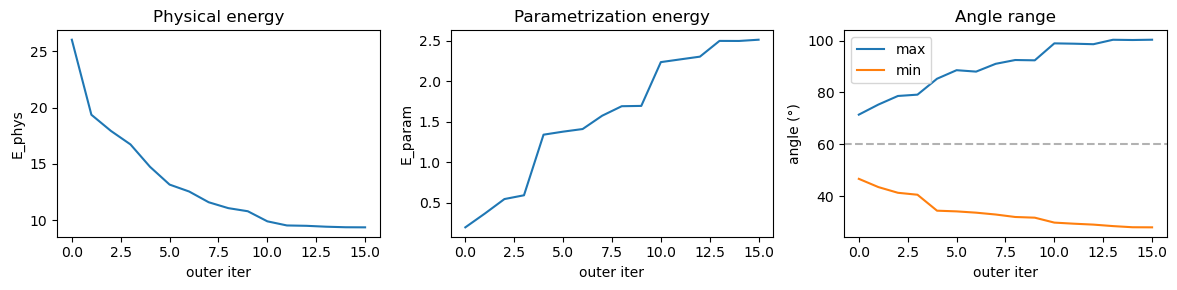

In [84]:
# convergence plot
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
iters = [h["iter"] for h in history]
axes[0].plot(iters, [h["E_phys"] for h in history])
axes[0].set(xlabel="outer iter", ylabel="E_phys", title="Physical energy")
axes[1].plot(iters, [h["E_param"] for h in history])
axes[1].set(xlabel="outer iter", ylabel="E_param", title="Parametrization energy")
axes[2].plot(iters, [h["max_angle"] for h in history], label="max")
axes[2].plot(iters, [h["min_angle"] for h in history], label="min")
axes[2].axhline(60, ls="--", color="k", alpha=0.3)
axes[2].set(xlabel="outer iter", ylabel="angle (°)", title="Angle range")
axes[2].legend()
fig.tight_layout()

In [85]:
# visualize initial and optimized shape
p = meshplot.plot(np.array(vertices_initial), np.array(hemesh.faces), shading={"wireframe": True},
                  return_plot=True)
p.add_mesh(np.array(v_opt) + np.array([3, 0, 0]), np.array(hemesh.faces), shading={"wireframe": True})
p.save("tutorial_plots/05_alternating_optimization.html")

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0, 0.0,…

Plot saved to file tutorial_plots/05_alternating_optimization.html.


In [86]:
IFrame(src="tutorial_plots/05_alternating_optimization.html", width="100%", height=400);

### Augmented Lagrangian method

A more systematic way to include the area and volume constraints is via two Lagrange multipliers $\lambda, p$, surface tension and pressure:   

$$\mathcal{L} = E_H - \lambda (A-A_0) -p (V-V_0) $$

Minimization under the boundary constraint is equivalent to stationarity of the Lagrangian (so-called KKLT-condition):

$$\nabla_\lambda \mathcal{L} = 0 \quad \mathrm{and} \quad \nabla_{\mathbf{v}} \mathcal{L} = 0 $$

Finding these stationary points - the aim of _numerical constrained minimization_ - can be quite challenging.
If the number of constraints (here, $2$) is small compared to the number of variables (here, $3\#\mathrm{vertices}$), _augmented Lagrangian methods_ are a suitable approach [(Nocedal & Wright, 2006)](https://link.springer.com/book/10.1007/978-0-387-40065-5).


Let's combine all constraints into a vectorial function $\mathbf{c}(\mathbf{x})$ so that $\mathbf{c}(\mathbf{x})=0$ when the constraint is fulfilled. All Lagrange multipliers are packaged into a vector $\lambda$. The _augmented Lagrangian_ $\mathcal{L}_A$ adds a quadratic penalty for constraint violations, with strength $\mu$:

$$\mathcal{L}_A = E(\mathbf{x}) -\lambda^T \cdot\mathbf{c}(\mathbf{x}) + \mu |\mathbf{c}(\mathbf{x})|^2$$

The AL method now iteratively (1) minimizes $\mathcal{L}_A$ w.r.t. to the variables $\mathbf{x}$ and (2) updates the Lagrange multiplier $\lambda$ and penalty strength $\mu$. The big advantage of the AL method compared to the naive approach of using only a penalty for constraint violation is that $\mu$ does not need to be increased to large values, which generally leads to numerical difficulties.

In [87]:
def augmented_lagrangian_method(objective_fn, constraints_fn, minimize_fn, x0,
                                lam0=None, mu0=10.0, mu_growth=2.0,
                                max_outer=15, tol=1e-4, verbose=True):
    """Generic augmented Lagrangian method for constrained minimization.

    Solves:  min objective_fn(x)  s.t. constraints_fn(x) = 0

    Parameters
    ----------
    objective_fn : callable
        Unconstrained objective: x → scalar.
    constraints_fn : callable
        Equality constraints: x → array of shape (m,). Satisfied when = 0.
    minimize_fn : callable
        Inner minimizer: (augmented_energy_fn, x0) → x_optimized.
        augmented_energy_fn has signature (x) → scalar.
    x0
        Initial guess for the variables.
    lam0 : array, optional
        Initial Lagrange multipliers. Default: zeros.
    mu0 : float
        Initial penalty parameter.
    mu_growth : float
        Factor by which μ is increased each iteration.
    max_outer : int
        Maximum number of outer AL iterations.
    tol : float
        Convergence tolerance on KKT residual √(|∇ₓL|² + |c|²).
    verbose : bool
        Print diagnostics each iteration.

    Returns
    -------
    x : optimized variables
    lam : final Lagrange multipliers
    history : list[dict] with keys 'objective', 'constraints', 'lam', 'mu',
              'c_norm', 'grad_norm', 'kkt_norm'
    """
    c0 = constraints_fn(x0)
    n_constraints = c0.shape[0]
    lam = jnp.zeros(n_constraints) if lam0 is None else lam0
    mu = mu0
    x = x0
    history = []

    for k in range(max_outer):
        # Capture current λ, μ in the augmented energy
        lam_k, mu_k = lam, mu
        def augmented_energy(x):
            c = constraints_fn(x)
            return objective_fn(x) - lam_k @ c + (mu_k / 2) * (c @ c)

        # Inner minimization
        x = minimize_fn(augmented_energy, x)

        # Evaluate KKT residual: ∇ₓL = ∇f - λᵀ∇c = 0 and c = 0
        c = constraints_fn(x)
        obj = float(objective_fn(x))
        c_norm = float(jnp.linalg.norm(c))

        lam_k_kkt = lam  # current multiplier estimate
        def lagrangian(x):
            return objective_fn(x) - lam_k_kkt @ constraints_fn(x)
        grad_L = jax.grad(lagrangian)(x)
        grad_norm = float(jnp.linalg.norm(grad_L))
        kkt_norm = float(jnp.sqrt(grad_norm**2 + c_norm**2))

        record = {"iter": k, "objective": obj, "constraints": np.array(c),
                  "lam": np.array(lam), "mu": mu, "c_norm": c_norm,
                  "grad_norm": grad_norm, "kkt_norm": kkt_norm}
        history.append(record)

        if verbose:
            c_str = ", ".join(f"{ci:.2e}" for ci in np.array(c))
            lam_str = ", ".join(f"{li:.4f}" for li in np.array(lam))
            print(f"  AL {k:2d} | obj={obj:.4f} | c=[{c_str}] | "
                  f"|∇L|={grad_norm:.2e} | λ=[{lam_str}] | μ={mu:.1f}")

        if kkt_norm < tol:
            if verbose:
                print(f"  Converged: KKT = {kkt_norm:.2e} < {tol:.0e}")
            break

        # Update multipliers and penalty
        lam = lam - mu * c
        mu = mu * mu_growth

    return x, lam, history

In [88]:
# --- Helfrich-specific wrappers for the AL method ---

def helfrich_objective(vertices):
    """Helfrich bending energy (no constraints)."""
    return get_helfrich_energy(vertices, (hemesh, H0, kappa))

def helfrich_constraints(vertices):
    """Equality constraints: [A - A0, V - V0]."""
    return jnp.array([geom.get_area(vertices, hemesh) - A0,
                      geom.get_volume(vertices, hemesh) - V0])

In [89]:
# --- Run: deflated sphere with AL + normal/tangential optimization ---

A0 = geom.get_area(trimesh.vertices, hemesh)
V0 = 0.75 * geom.get_volume(trimesh.vertices, hemesh)
kappa, H0 = 1.0, 0.0
metric_ref = get_metric(trimesh.vertices, hemesh)
#args_conformal = (hemesh, metric_ref)

mod_bulk, mod_shear = 1.0, 1.0
args_elastic = (hemesh, metric_ref, mod_bulk, mod_shear)


# start from a slightly stretched sphere to break symmetry
vertices_initial = trimesh.vertices * np.array([0.95, 1.1, 0.95])

# inner minimizer: alternating normal/tangential with conformal regularization
def minimize_fn(energy_fn, vertices):
    v_opt, _ = alternating_minimize(
        lambda v, args: energy_fn(v), None,
        #get_conformal_energy, args_conformal,
        get_neo_hookean_energy, args_elastic,
        vertices, hemesh,
        n_outer=15, n_inner_normal=100, n_inner_tangential=50,
        verbose=False)
    return v_opt

# run the augmented Lagrangian method
v_al, lam_al, history_al = augmented_lagrangian_method(
    helfrich_objective, helfrich_constraints, minimize_fn,
    vertices_initial,
    mu0=10.0, mu_growth=2.0, max_outer=6, tol=1e-4)

  AL  0 | obj=7.6403 | c=[-2.03e-01, 4.90e-01] | |∇L|=2.39e+00 | λ=[0.0000, 0.0000] | μ=10.0
  AL  1 | obj=9.3853 | c=[8.24e-03, 2.57e-02] | |∇L|=3.16e+00 | λ=[2.0316, -4.8952] | μ=20.0
  AL  2 | obj=9.6090 | c=[9.55e-03, -3.48e-02] | |∇L|=2.58e-01 | λ=[1.8669, -5.4091] | μ=40.0
  AL  3 | obj=9.4756 | c=[1.03e-03, -3.35e-03] | |∇L|=9.64e-02 | λ=[1.4848, -4.0174] | μ=80.0
  AL  4 | obj=9.4602 | c=[-1.23e-04, 3.13e-04] | |∇L|=1.41e-02 | λ=[1.4024, -3.7496] | μ=160.0
  AL  5 | obj=9.4615 | c=[-4.15e-06, 1.16e-05] | |∇L|=1.17e-02 | λ=[1.4220, -3.7997] | μ=320.0


In [94]:
# --- Diagnostics ---

E_al = get_helfrich_energy(v_al, (hemesh, H0, kappa))
print(f"Helfrich energy: {E_al:.4f}")
print(f"A/A0 = {geom.get_area(v_al, hemesh)/A0:.6f},  V/V0 = {geom.get_volume(v_al, hemesh)/V0:.6f}")
print(f"Lagrange multipliers (tension, pressure): λ = {lam_al}")
print(f"Final μ: {history_al[-1]['mu']:.1f}")
algo.get_mesh_quality_stats(v_al, hemesh)

Helfrich energy: 9.4615
A/A0 = 1.000000,  V/V0 = 1.000004
Lagrange multipliers (tension, pressure): λ = [ 1.42332769 -3.80344206]
Final μ: 320.0


{'areas_min': 0.00533,
 'areas_max': 0.0166,
 'areas_cv': 0.3592,
 'max_angle': 104.6414,
 'min_angle': 24.6517,
 'angles_std': 20.42506,
 'n_degenerate': 0,
 'n_total_faces': 1280}

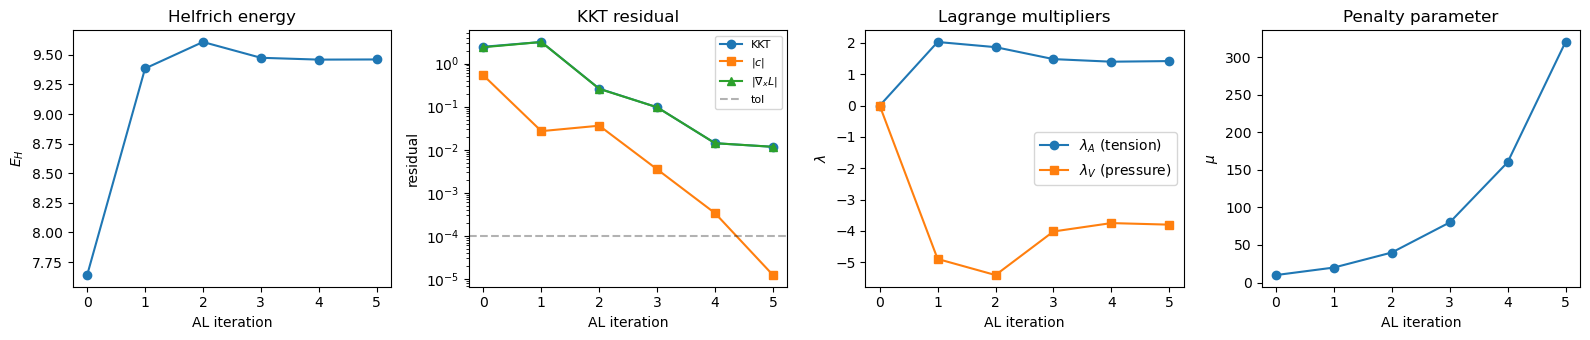

In [95]:
# --- Convergence plots ---

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
iters = [h["iter"] for h in history_al]

axes[0].plot(iters, [h["objective"] for h in history_al], "o-")
axes[0].set(xlabel="AL iteration", ylabel="$E_H$", title="Helfrich energy")

axes[1].semilogy(iters, [h["kkt_norm"] for h in history_al], "o-", label="KKT")
axes[1].semilogy(iters, [h["c_norm"] for h in history_al], "s-", label="$|c|$")
axes[1].semilogy(iters, [h["grad_norm"] for h in history_al], "^-", label="$|\\nabla_x L|$")
axes[1].axhline(1e-4, ls="--", color="k", alpha=0.3, label="tol")
axes[1].set(xlabel="AL iteration", ylabel="residual", title="KKT residual")
axes[1].legend(fontsize=8)

lam_A = [h["lam"][0] for h in history_al]
lam_V = [h["lam"][1] for h in history_al]
axes[2].plot(iters, lam_A, "o-", label="$\\lambda_A$ (tension)")
axes[2].plot(iters, lam_V, "s-", label="$\\lambda_V$ (pressure)")
axes[2].set(xlabel="AL iteration", ylabel="$\\lambda$", title="Lagrange multipliers")
axes[2].legend()

axes[3].plot(iters, [h["mu"] for h in history_al], "o-")
axes[3].set(xlabel="AL iteration", ylabel="$\\mu$", title="Penalty parameter")

fig.tight_layout()

In [96]:
# --- Visualize initial and AL-optimized shape ---
p = meshplot.plot(np.array(vertices_initial), np.array(hemesh.faces), shading={"wireframe": True}, return_plot=True)
p.add_mesh(np.array(v_al) + np.array([3, 0, 0]), np.array(hemesh.faces), shading={"wireframe": True})
p.save("tutorial_plots/05_augmented_lagrangian_optimization.html")

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0, 0.0,…

Plot saved to file tutorial_plots/05_augmented_lagrangian_optimization.html.


In [97]:
IFrame(src="tutorial_plots/05_augmented_lagrangian_optimization.html", width="100%", height=400);